# Consolidación de Telemetría de UAV (Drones) Paso a Paso

Este cuaderno Jupyter automatiza la consolidación, normalización de marcas de tiempo y combinación de archivos de telemetría en formato JSON correspondientes a dos vuelos de drones (`drone1` y `drone2`). El resultado final es un dataset unificado en formato CSV, ordenado cronológicamente y listo para el análisis.

### Objetivos del Proceso:
1. **Explorar** y verificar la estructura de archivos de telemetría de cada drone.
2. **Cargar** de forma secuencial y ordenada los registros JSON individuales.
3. **Normalizar** las marcas de tiempo de Facebook (milisegundos desde la época Unix) a formato estándar ISO 8601 UTC.
4. **Combinar y Ordenar** los datos de ambos vuelos cronológicamente en un único DataFrame de Pandas.
5. **Visualizar** las trayectorias de vuelo (2D) y perfiles de altitud de los drones.
6. **Exportar** el dataset unificado a un archivo CSV consolidado.

## Paso 1: Configuración de Entorno e Importaciones

Comenzamos importando las librerías necesarias. Además de las librerías estándar de Python utilizadas en el script original (`os`, `json`, `csv`, `datetime`, `pathlib`), añadimos `pandas` y `matplotlib` para permitir una visualización y análisis de datos interactivo.

In [1]:
import os
import json 
import csv
from datetime import datetime, timezone
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Configurar los gráficos de matplotlib en línea
%matplotlib inline

## Paso 2: Funciones Auxiliares de Conversión y Extracción

Definimos las funciones que se encargarán del tratamiento de las marcas de tiempo:

- `facebook_timestamp_to_iso`: Los registros originales utilizan un formato de milisegundos. Esta función convierte ese valor a un formato ISO 8601 UTC (`YYYY-MM-DDTHH:MM:SS.mmmZ`) utilizando objetos conscientes de zona horaria (`timezone.utc`) para evitar advertencias de obsolescencia.
- `extract_timestamp_from_filename`: Los nombres de los archivos JSON siguen el patrón `message_TIMESTAMP.json`. Extraemos la porción numérica del nombre para usarla como la marca de tiempo de ordenación de cada registro.

In [2]:
def facebook_timestamp_to_iso(timestamp_ms):
    """
    Convierte un timestamp en milisegundos (Facebook format) a formato ISO 8601 UTC.
    """
    try:
        timestamp_ms = int(timestamp_ms)
        timestamp_s = timestamp_ms / 1000.0
        # Convertir a datetime UTC consciente de la zona horaria
        dt = datetime.fromtimestamp(timestamp_s, timezone.utc)
        return dt.isoformat().replace('+00:00', 'Z')
    except (ValueError, OverflowError) as e:
        print(f"Error al convertir timestamp {timestamp_ms}: {e}")
        return None

def extract_timestamp_from_filename(filename):
    """
    Extrae el timestamp numérico (milisegundos) a partir del nombre del archivo JSON.
    """
    try:
        # Quitar la extensión .json y el prefijo message_
        name_without_ext = filename.replace('.json', '')
        timestamp_str = name_without_ext.replace('message_', '')
        return int(timestamp_str)
    except ValueError:
        return None

## Paso 3: Configuración de Rutas de Datos

Establecemos de manera robusta las rutas hacia las carpetas que contienen la telemetría de cada drone utilizando `pathlib.Path` para evitar errores de directorios relativos o de sistemas operativos.

In [3]:
# Ruta al directorio del cuaderno actual
notebook_dir = Path().resolve()

# Definir directorios de entrada y archivo de salida
drone1_dir = notebook_dir / "UAV_telemetry_dataset" / "flightplan_drone1"
drone2_dir = notebook_dir / "UAV_telemetry_dataset" / "flightplan_drone2"
output_csv = notebook_dir / "consolidated_telemetry.csv"

# Mostrar y verificar la existencia de los directorios
print(f"Directorio Drone 1: {drone1_dir} (Existe: {drone1_dir.exists()})")
print(f"Directorio Drone 2: {drone2_dir} (Existe: {drone2_dir.exists()})")
print(f"Ruta de salida del CSV consolidado: {output_csv}")

Directorio Drone 1: D:\TesisMCD\lm-drone\callibration_flight\actual_telemetry\UAV_telemetry_dataset\flightplan_drone1 (Existe: True)
Directorio Drone 2: D:\TesisMCD\lm-drone\callibration_flight\actual_telemetry\UAV_telemetry_dataset\flightplan_drone2 (Existe: True)
Ruta de salida del CSV consolidado: D:\TesisMCD\lm-drone\callibration_flight\actual_telemetry\consolidated_telemetry.csv


## Paso 4: Carga y Procesamiento de la Telemetría Individual

Esta función recorre los directorios indicados, lee los archivos JSON correspondientes a las lecturas ordenados secuencialmente por su timestamp, extrae y convierte su marca de tiempo, y junta todo en una única lista de diccionarios.

In [4]:
def load_telemetry_files(directory_paths):
    """
    Carga todos los archivos JSON de telemetría de los directorios proporcionados.
    """
    telemetry_data = []
    
    for dir_path in directory_paths:
        dir_path = Path(dir_path)
        if not dir_path.exists():
            print(f"Advertencia: El directorio {dir_path} no existe")
            continue
        
        print(f"Procesando directorio: {dir_path.name}")
        
        # Listar y ordenar todos los archivos JSON por su timestamp en el nombre
        json_files = sorted(
            [f for f in dir_path.glob('*.json')],
            key=lambda f: extract_timestamp_from_filename(f.name) or 0
        )
        
        print(f"-> Encontrados {len(json_files)} archivos de telemetría")
        
        for filepath in json_files:
            filename = filepath.name
            timestamp_ms = extract_timestamp_from_filename(filename)
            
            if timestamp_ms is None:
                print(f"Advertencia: No se pudo extraer el timestamp del archivo {filename}")
                continue
            
            try:
                with open(filepath, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                
                # Agregar las marcas de tiempo procesadas
                data['timestamp_iso'] = facebook_timestamp_to_iso(timestamp_ms)
                data['timestamp_ms'] = timestamp_ms
                
                telemetry_data.append(data)
                
            except json.JSONDecodeError as e:
                print(f"Error al leer JSON de {filename}: {e}")
            except Exception as e:
                print(f"Error al procesar {filename}: {e}")
                
    return telemetry_data

# Ejecutar la carga para ambas rutas
raw_telemetry = load_telemetry_files([drone1_dir, drone2_dir])
print(f"\nCarga finalizada. Total de registros en memoria: {len(raw_telemetry)}")

Procesando directorio: flightplan_drone1
-> Encontrados 329 archivos de telemetría
Procesando directorio: flightplan_drone2
-> Encontrados 456 archivos de telemetría

Carga finalizada. Total de registros en memoria: 785


## Paso 5: Creación del DataFrame y Ordenación

Cargamos los datos consolidados en un DataFrame de Pandas. Esto nos permite estructurar la información en forma de tabla, limpiar registros inconsistentes si los hubiera y ordenar el dataset de forma global por la columna `timestamp_ms`.

In [5]:
# Crear DataFrame de Pandas
df_telemetry = pd.DataFrame(raw_telemetry)

# Ordenar los datos por marca de tiempo (cronológicamente)
df_telemetry = df_telemetry.sort_values(by='timestamp_ms').reset_index(drop=True)

# Visualizar las dimensiones y las primeras filas
print(f"Forma del DataFrame consolidado: {df_telemetry.shape} (filas, columnas)")
df_telemetry.head(10)

Forma del DataFrame consolidado: (785, 18) (filas, columnas)


,droneID,aircraftLongitude,aircraftLatitude,aircraftAltitude,distanceToHome,homeAltitude,homeLatitude,homeLongitude,gimbal_PITCH,gimbal_YAW,gimbal_ROLL,headingDroneDegress,isInMission,missionPlan,currentWaypointMissionPlanner,batteryPercentage,timestamp_iso,timestamp_ms
0,drone1,-4.526,55.788,1.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.98,2025-07-14T15:31:55.773000Z,1752507115773
1,drone1,-4.526,55.788,2.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.96,2025-07-14T15:31:55.974000Z,1752507115974
2,drone1,-4.526,55.788,3.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.94,2025-07-14T15:31:56.174000Z,1752507116174
3,drone1,-4.526,55.788,4.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.92,2025-07-14T15:31:56.375000Z,1752507116375
4,drone1,-4.526,55.788,5.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.90,2025-07-14T15:31:56.576000Z,1752507116576
5,drone1,-4.526,55.788,6.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.88,2025-07-14T15:31:56.777000Z,1752507116777
6,drone1,-4.526,55.788,7.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.86,2025-07-14T15:31:56.978000Z,1752507116978
7,drone1,-4.526,55.788,8.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.84,2025-07-14T15:31:57.179000Z,1752507117179
8,drone1,-4.526,55.788,9.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.82,2025-07-14T15:31:57.380000Z,1752507117380
9,drone1,-4.526,55.788,10.0,0,0,4.58,4.58,7.6,-71.9,0.0,-92.0,False,None,NaN,44.80,2025-07-14T15:31:57.581000Z,1752507117581


## Paso 6: Inspección y Estadísticas Descriptivas

Analizamos el contenido de los datos para entender las variables, tipos de datos y estadísticas generales de los parámetros de los vuelos.

In [6]:
# Mostrar información de los tipos de datos y nulos
df_telemetry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   droneID                        785 non-null    object 
 1   aircraftLongitude              785 non-null    float64
 2   aircraftLatitude               785 non-null    float64
 3   aircraftAltitude               785 non-null    float64
 4   distanceToHome                 785 non-null    int64  
 5   homeAltitude                   785 non-null    int64  
 6   homeLatitude                   785 non-null    float64
 7   homeLongitude                  785 non-null    float64
 8   gimbal_PITCH                   785 non-null    float64
 9   gimbal_YAW                     785 non-null    float64
 10  gimbal_ROLL                    785 non-null    float64
 11  headingDroneDegress            785 non-null    float64
 12  isInMission                    785 non-null    boo

In [7]:
# Estadísticas descriptivas básicas de los parámetros numéricos
df_telemetry.describe()

,aircraftLongitude,aircraftLatitude,aircraftAltitude,distanceToHome,homeAltitude,homeLatitude,homeLongitude,gimbal_PITCH,gimbal_YAW,gimbal_ROLL,headingDroneDegress,currentWaypointMissionPlanner,batteryPercentage,timestamp_ms
count,785.000000,785.000000,785.000000,785.0,785.0,7.850000e+02,7.850000e+02,785.000000,785.000000,785.0,785.000000,725.000000,785.000000,7.850000e+02
mean,-4.528117,55.788654,28.891720,0.0,0.0,4.580000e+00,4.580000e+00,2.276973,-56.680310,0.0,111.644935,2.822069,62.499783,1.752508e+12
std,0.002215,0.000703,4.538075,0.0,0.0,8.887447e-16,8.887447e-16,15.579661,21.325210,0.0,124.843649,1.923268,22.478894,3.190018e+05
min,-4.532130,55.787700,1.000000,0.0,0.0,4.580000e+00,4.580000e+00,-27.071336,-82.757906,0.0,-92.000000,0.000000,29.450000,1.752507e+12
25%,-4.529430,55.788200,30.000000,0.0,0.0,4.580000e+00,4.580000e+00,-11.883392,-73.330627,0.0,0.000000,1.000000,39.250000,1.752507e+12
50%,-4.528430,55.788500,30.000000,0.0,0.0,4.580000e+00,4.580000e+00,5.554932,-69.631565,0.0,89.999999,3.000000,68.990000,1.752508e+12
75%,-4.526000,55.789480,30.000000,0.0,0.0,4.580000e+00,4.580000e+00,9.793016,-33.871650,0.0,234.714079,4.000000,82.710000,1.752508e+12
max,-4.524810,55.789680,30.000000,0.0,0.0,4.580000e+00,4.580000e+00,39.723158,-11.297916,0.0,304.880675,6.000000,94.980000,1.752508e+12


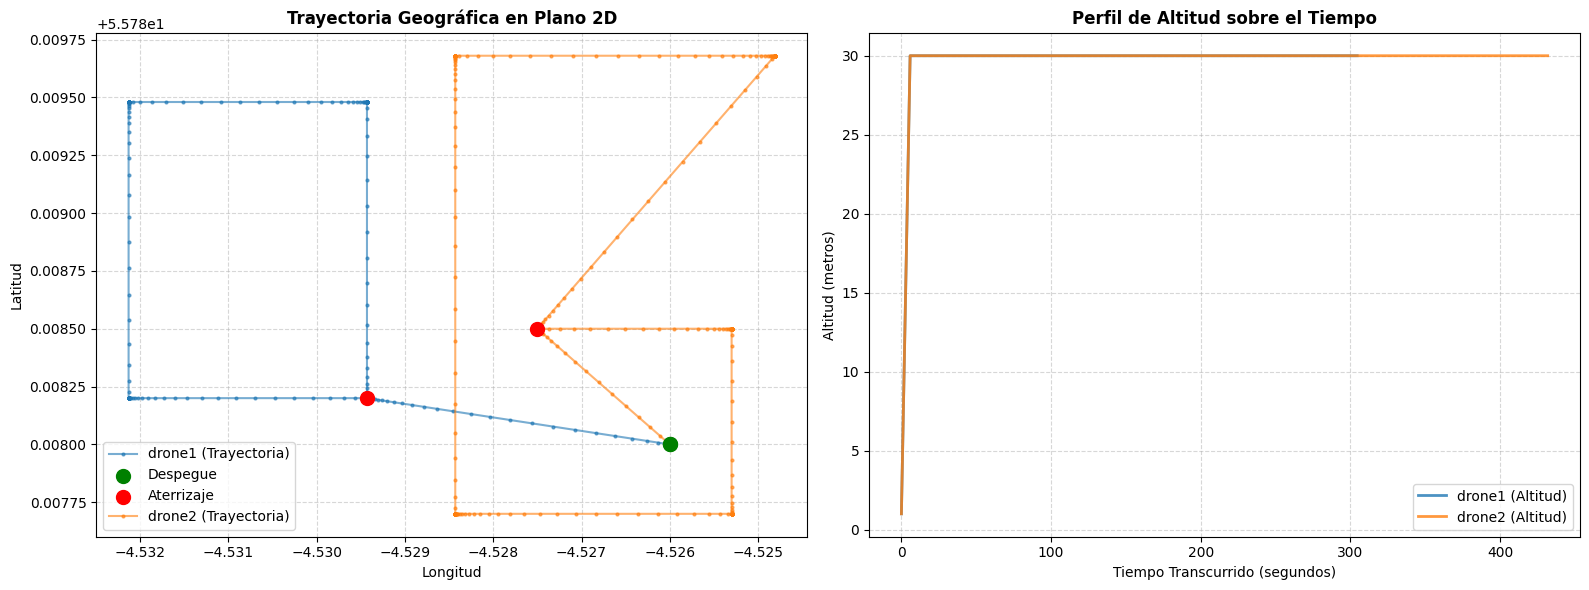

In [8]:
# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colores para diferenciar los drones
colors = {'drone1': '#1f77b4', 'drone2': '#ff7f0e'}

# 1. Trayectoria Geográfica
ax1 = axes[0]
for drone_id, group in df_telemetry.groupby('droneID'):
    ax1.plot(group['aircraftLongitude'], group['aircraftLatitude'], 
             label=f"{drone_id} (Trayectoria)", color=colors.get(drone_id, 'gray'), 
             marker='.', markersize=4, linestyle='-', alpha=0.6)
    
    # Marcar los puntos de inicio (despegue) y fin
    ax1.scatter(group['aircraftLongitude'].iloc[0], group['aircraftLatitude'].iloc[0], 
                color='green', s=100, zorder=5, label='Despegue' if drone_id == 'drone1' else "")
    ax1.scatter(group['aircraftLongitude'].iloc[-1], group['aircraftLatitude'].iloc[-1], 
                color='red', s=100, zorder=5, label='Aterrizaje' if drone_id == 'drone1' else "")

ax1.set_title('Trayectoria Geográfica en Plano 2D', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitud', fontsize=10)
ax1.set_ylabel('Latitud', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# 2. Perfil de Altitud sobre el tiempo
ax2 = axes[1]
for drone_id, group in df_telemetry.groupby('droneID'):
    # Tiempo transcurrido en segundos desde el inicio de cada vuelo
    start_time = group['timestamp_ms'].min()
    elapsed_seconds = (group['timestamp_ms'] - start_time) / 1000.0
    
    ax2.plot(elapsed_seconds, group['aircraftAltitude'], 
             label=f"{drone_id} (Altitud)", color=colors.get(drone_id, 'gray'), 
             linewidth=2, alpha=0.8)

ax2.set_title('Perfil de Altitud sobre el Tiempo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tiempo Transcurrido (segundos)', fontsize=10)
ax2.set_ylabel('Altitud (metros)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

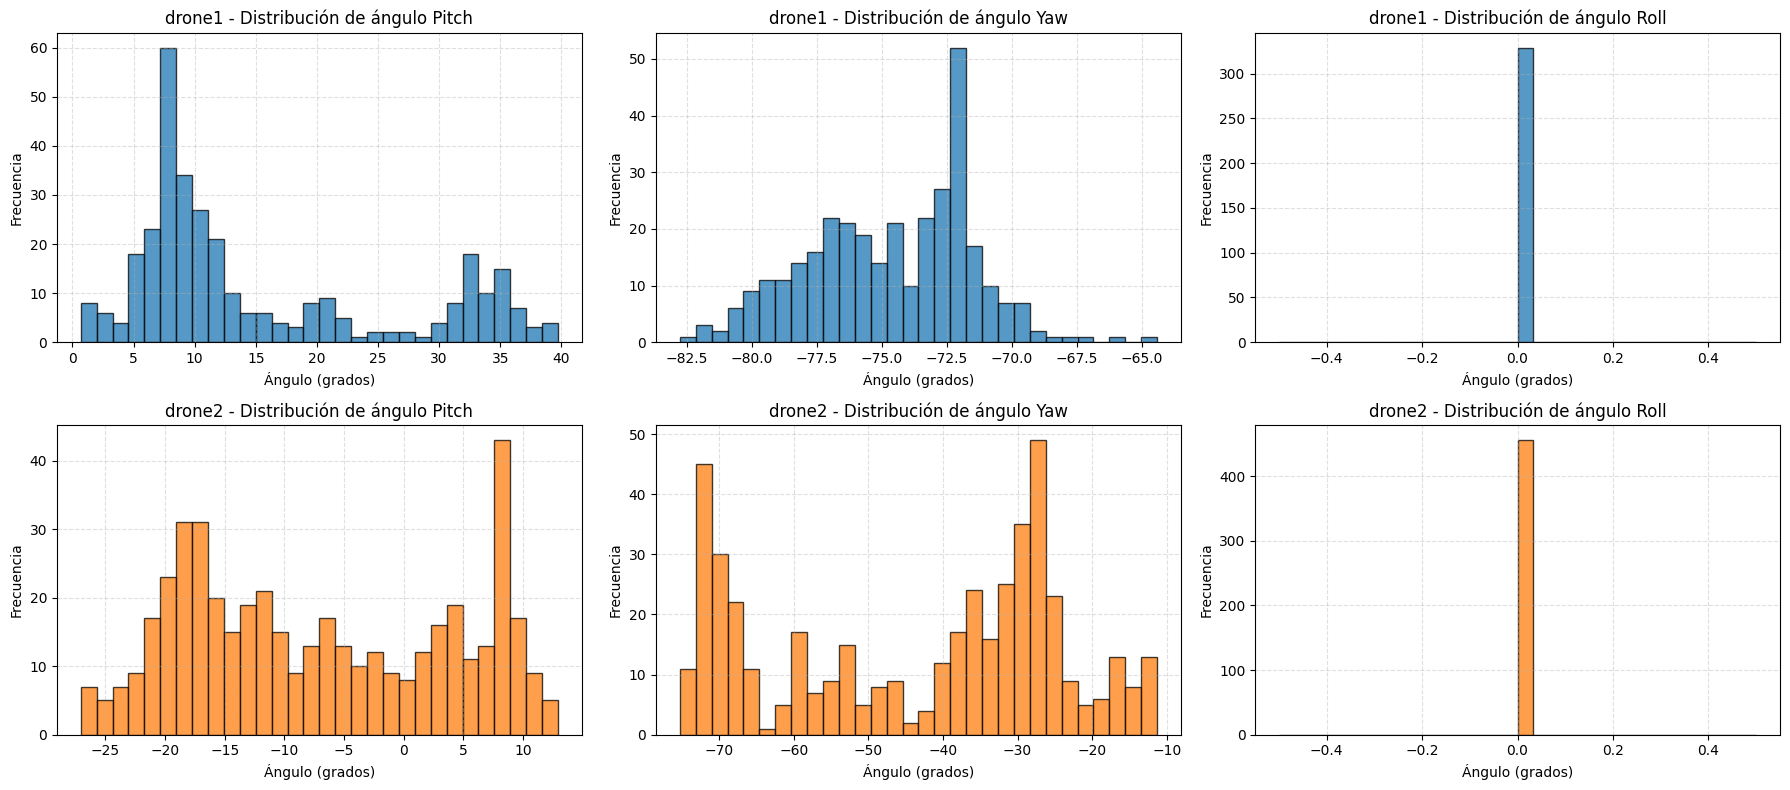

In [9]:
# Histograma de distribución de ángulos gimbal (PITCH, YAW, ROLL) por drone

colors = {'drone1': '#1f77b4', 'drone2': '#ff7f0e'}
drones = sorted(df_telemetry['droneID'].dropna().unique())

gimbal_cols = ['gimbal_PITCH', 'gimbal_YAW', 'gimbal_ROLL']
titles = ['Distribución de ángulo Pitch', 'Distribución de ángulo Yaw', 'Distribución de ángulo Roll']

# Distribuciones de gimbal en dos filas: una fila por drone

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)

for row_idx, drone_id in enumerate(drones):
    for col_idx, (col, title) in enumerate(zip(gimbal_cols, titles)):
        subset = df_telemetry.loc[df_telemetry['droneID'] == drone_id, col].dropna()
        
        axes[row_idx, col_idx].hist(
            subset,
            bins=30,
            alpha=0.75,
            color=colors.get(drone_id, 'gray'),
            edgecolor='black'
        )
        
        axes[row_idx, col_idx].set_title(f"{drone_id} - {title}")
        axes[row_idx, col_idx].set_xlabel('Ángulo (grados)')
        axes[row_idx, col_idx].set_ylabel('Frecuencia')
        axes[row_idx, col_idx].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Calculo de velocidad en cada eje

In [10]:
import numpy as np

# Asegurar que los datos están ordenados por dron y tiempo
df_telemetry = df_telemetry.sort_values(by=['droneID', 'timestamp_ms']).reset_index(drop=True)

# Radio de la Tierra en metros (aproximación local)
R = 6378137.0

# Diferencias de tiempo en segundos
df_telemetry['dt'] = df_telemetry.groupby('droneID')['timestamp_ms'].diff() / 1000.0

# Diferencias de coordenadas en radianes
df_telemetry['dlat'] = np.radians(df_telemetry.groupby('droneID')['aircraftLatitude'].diff())
df_telemetry['dlon'] = np.radians(df_telemetry.groupby('droneID')['aircraftLongitude'].diff())
df_telemetry['dz'] = df_telemetry.groupby('droneID')['aircraftAltitude'].diff()

# Latitud promedio en radianes por intervalo para corregir dx
lat_rad = np.radians(df_telemetry['aircraftLatitude'])
mean_lat_rad = lat_rad - (df_telemetry['dlat'] / 2.0)

# Distancias físicas en metros en cada eje
df_telemetry['dx'] = df_telemetry['dlon'] * R * np.cos(mean_lat_rad)
df_telemetry['dy'] = df_telemetry['dlat'] * R

# Calcular velocidades (m/s) controlando valores del primer registro de cada dron
df_telemetry['vx'] = np.where(df_telemetry['dt'] > 0, df_telemetry['dx'] / df_telemetry['dt'], 0.0)
df_telemetry['vy'] = np.where(df_telemetry['dt'] > 0, df_telemetry['dy'] / df_telemetry['dt'], 0.0)
df_telemetry['vz'] = np.where(df_telemetry['dt'] > 0, df_telemetry['dz'] / df_telemetry['dt'], 0.0)

# Velocidad total resultante
df_telemetry['v_total'] = np.sqrt(df_telemetry['vx']**2 + df_telemetry['vy']**2 + df_telemetry['vz']**2)

# Eliminar columnas auxiliares para mantener limpio el DataFrame
df_telemetry.drop(columns=['dt', 'dlat', 'dlon', 'dz', 'dx', 'dy'], inplace=True)

# Mostrar estadísticas descriptivas de las nuevas velocidades y las primeras filas
print(df_telemetry[['vx', 'vy', 'vz', 'v_total']].describe())
df_telemetry[['droneID', 'timestamp_ms', 'vx', 'vy', 'vz', 'v_total']].head(10)


               vx          vy          vz       v_total
count  785.000000  785.000000  785.000000  7.850000e+02
mean    -0.418807    0.107635    0.367842  2.979155e+00
std      4.263830    3.004140    1.303144  4.509912e+00
min    -15.422624  -12.703677    0.000000  0.000000e+00
25%     -0.000012    0.000000    0.000000  7.104544e-09
50%      0.000000    0.000000    0.000000  2.907311e-02
75%      0.000000    0.000000    0.000000  4.975124e+00
max     15.846635   15.616114    5.000000  1.584664e+01


,droneID,timestamp_ms,vx,vy,vz,v_total
0,drone1,1752507115773,0.0,0.0,0.000000,0.000000
1,drone1,1752507115974,0.0,0.0,4.975124,4.975124
2,drone1,1752507116174,0.0,0.0,5.000000,5.000000
3,drone1,1752507116375,0.0,0.0,4.975124,4.975124
4,drone1,1752507116576,0.0,0.0,4.975124,4.975124
5,drone1,1752507116777,0.0,0.0,4.975124,4.975124
6,drone1,1752507116978,0.0,0.0,4.975124,4.975124
7,drone1,1752507117179,0.0,0.0,4.975124,4.975124
8,drone1,1752507117380,0.0,0.0,4.975124,4.975124
9,drone1,1752507117581,0.0,0.0,4.975124,4.975124


## Paso 8: Exportar Dataset Consolidado a CSV

Por último, guardamos el DataFrame ordenado a un archivo CSV. Nos aseguramos de ubicar los campos más importantes al inicio (`timestamp_iso`, `timestamp_ms` y `droneID`) y el resto de las variables ordenadas alfabéticamente.

In [11]:
# Reordenar columnas para tener los metadatos de tiempo e ID primero
headers = ['timestamp_iso', 'timestamp_ms', 'droneID']
other_keys = sorted([k for k in df_telemetry.columns if k not in headers])
final_headers = headers + other_keys

df_final = df_telemetry[final_headers]

# Guardar en archivo CSV
df_final.to_csv(output_csv, index=False, encoding='utf-8')

print(f"¡Éxito! Se consolidaron {len(df_final)} registros.")
print(f"El dataset consolidado se guardó en: {output_csv.name}")

¡Éxito! Se consolidaron 785 registros.
El dataset consolidado se guardó en: consolidated_telemetry.csv
